In [48]:
import pandas as pd
import japanize_matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn import preprocessing

In [51]:
df = pd.read_excel('..\data\iryoaccess.xlsx')


In [52]:
df

,Unnamed: 0,地域区分,高齢世帯の型,住宅の所有の関係,0_総数,1_250ｍ未満,2_250～500ｍ未満,"3_500～1,000ｍ未満","4_1,000ｍ以上"
0,a,00000_全国,0_総数,0_総数,14486000,3809100,4080700,3573800,3022400
1,a,00000_全国,0_総数,1_持ち家,11159300,2625900,2981200,2833900,2718300
2,a,00000_全国,0_総数,2_借家,3292500,1176900,1090300,730700,294500
3,a,00000_全国,0_総数,21_公営の借家,853000,223400,276000,237000,116700
4,a,00000_全国,0_総数,22_都市再生機構(UR)・公社の借家,308100,135100,115200,49700,8100
...,...,...,...,...,...,...,...,...,...
8068,a,47000_沖縄県,S2_（別掲）75歳以上の世帯員のいる世帯,22_都市再生機構(UR)・公社の借家,-,-,-,-,-
8069,a,47000_沖縄県,S2_（別掲）75歳以上の世帯員のいる世帯,23_民営借家,22800,7100,7800,5200,2700
8070,a,47000_沖縄県,S2_（別掲）75歳以上の世帯員のいる世帯,231_民営借家（木造）,500,100,100,100,100
8071,a,47000_沖縄県,S2_（別掲）75歳以上の世帯員のいる世帯,232_民営借家（非木造）,22300,7000,7700,5100,2600


In [91]:
df_all = df[(df['地域区分']!='00000_全国')&(df['高齢世帯の型']=='0_総数')&(df['住宅の所有の関係']=='0_総数')&(df['Unnamed: 0']=='a')]

In [92]:
df_all

,Unnamed: 0,地域区分,高齢世帯の型,住宅の所有の関係,0_総数,1_250ｍ未満,2_250～500ｍ未満,"3_500～1,000ｍ未満","4_1,000ｍ以上"
117,a,01000_北海道,0_総数,0_総数,756100,147400,211300,215800,181600
351,a,02000_青森県,0_総数,0_総数,132600,10300,22700,38800,60800
468,a,03000_岩手県,0_総数,0_総数,126000,11600,19000,32900,62500
585,a,04000_宮城県,0_総数,0_総数,232800,35900,53500,72700,70700
819,a,05000_秋田県,0_総数,0_総数,108200,13500,22000,27800,44900
936,a,06000_山形県,0_総数,0_総数,100800,14100,23600,24600,38600
1053,a,07000_福島県,0_総数,0_総数,191200,30000,40600,42900,77700
1170,a,08000_茨城県,0_総数,0_総数,305000,33200,62600,87100,122100
1287,a,09000_栃木県,0_総数,0_総数,202600,43400,46100,47000,66100
1404,a,10000_群馬県,0_総数,0_総数,218600,34900,58800,63100,61800


In [93]:
df_all = df_all[~df_all['地域区分'].str.contains('市','区', na=False)]

In [94]:
df_all

,Unnamed: 0,地域区分,高齢世帯の型,住宅の所有の関係,0_総数,1_250ｍ未満,2_250～500ｍ未満,"3_500～1,000ｍ未満","4_1,000ｍ以上"
117,a,01000_北海道,0_総数,0_総数,756100,147400,211300,215800,181600
351,a,02000_青森県,0_総数,0_総数,132600,10300,22700,38800,60800
468,a,03000_岩手県,0_総数,0_総数,126000,11600,19000,32900,62500
585,a,04000_宮城県,0_総数,0_総数,232800,35900,53500,72700,70700
819,a,05000_秋田県,0_総数,0_総数,108200,13500,22000,27800,44900
936,a,06000_山形県,0_総数,0_総数,100800,14100,23600,24600,38600
1053,a,07000_福島県,0_総数,0_総数,191200,30000,40600,42900,77700
1170,a,08000_茨城県,0_総数,0_総数,305000,33200,62600,87100,122100
1287,a,09000_栃木県,0_総数,0_総数,202600,43400,46100,47000,66100
1404,a,10000_群馬県,0_総数,0_総数,218600,34900,58800,63100,61800


In [95]:
df_all['地域区分'] = df_all['地域区分'].str.slice(6)

In [96]:
df_all

,Unnamed: 0,地域区分,高齢世帯の型,住宅の所有の関係,0_総数,1_250ｍ未満,2_250～500ｍ未満,"3_500～1,000ｍ未満","4_1,000ｍ以上"
117,a,北海道,0_総数,0_総数,756100,147400,211300,215800,181600
351,a,青森県,0_総数,0_総数,132600,10300,22700,38800,60800
468,a,岩手県,0_総数,0_総数,126000,11600,19000,32900,62500
585,a,宮城県,0_総数,0_総数,232800,35900,53500,72700,70700
819,a,秋田県,0_総数,0_総数,108200,13500,22000,27800,44900
936,a,山形県,0_総数,0_総数,100800,14100,23600,24600,38600
1053,a,福島県,0_総数,0_総数,191200,30000,40600,42900,77700
1170,a,茨城県,0_総数,0_総数,305000,33200,62600,87100,122100
1287,a,栃木県,0_総数,0_総数,202600,43400,46100,47000,66100
1404,a,群馬県,0_総数,0_総数,218600,34900,58800,63100,61800


In [97]:
distance_cols = ['1_250ｍ未満', '2_250～500ｍ未満', '3_500～1,000ｍ未満', '4_1,000ｍ以上']

# 各距離の割合を計算して新しい列を追加
for col in distance_cols:
    df_all[col + '_割合'] = df_all[col] / df_all['0_総数']

# 確認
df_all[['0_総数'] + distance_cols + [c + '_割合' for c in distance_cols]].head()

,0_総数,1_250ｍ未満,2_250～500ｍ未満,"3_500～1,000ｍ未満","4_1,000ｍ以上",1_250ｍ未満_割合,2_250～500ｍ未満_割合,"3_500～1,000ｍ未満_割合","4_1,000ｍ以上_割合"
117,756100,147400,211300,215800,181600,0.194948,0.27946,0.285412,0.24018
351,132600,10300,22700,38800,60800,0.077677,0.171192,0.292609,0.458522
468,126000,11600,19000,32900,62500,0.092063,0.150794,0.261111,0.496032
585,232800,35900,53500,72700,70700,0.15421,0.229811,0.312285,0.303694
819,108200,13500,22000,27800,44900,0.124769,0.203327,0.256932,0.414972


In [98]:
df_all

,Unnamed: 0,地域区分,高齢世帯の型,住宅の所有の関係,0_総数,1_250ｍ未満,2_250～500ｍ未満,"3_500～1,000ｍ未満","4_1,000ｍ以上",1_250ｍ未満_割合,2_250～500ｍ未満_割合,"3_500～1,000ｍ未満_割合","4_1,000ｍ以上_割合"
117,a,北海道,0_総数,0_総数,756100,147400,211300,215800,181600,0.194948,0.27946,0.285412,0.24018
351,a,青森県,0_総数,0_総数,132600,10300,22700,38800,60800,0.077677,0.171192,0.292609,0.458522
468,a,岩手県,0_総数,0_総数,126000,11600,19000,32900,62500,0.092063,0.150794,0.261111,0.496032
585,a,宮城県,0_総数,0_総数,232800,35900,53500,72700,70700,0.15421,0.229811,0.312285,0.303694
819,a,秋田県,0_総数,0_総数,108200,13500,22000,27800,44900,0.124769,0.203327,0.256932,0.414972
936,a,山形県,0_総数,0_総数,100800,14100,23600,24600,38600,0.139881,0.234127,0.244048,0.382937
1053,a,福島県,0_総数,0_総数,191200,30000,40600,42900,77700,0.156904,0.212343,0.224372,0.406381
1170,a,茨城県,0_総数,0_総数,305000,33200,62600,87100,122100,0.108852,0.205246,0.285574,0.400328
1287,a,栃木県,0_総数,0_総数,202600,43400,46100,47000,66100,0.214215,0.227542,0.231984,0.326259
1404,a,群馬県,0_総数,0_総数,218600,34900,58800,63100,61800,0.159652,0.268984,0.288655,0.282708


In [99]:
import pandas as pd

# 変換したい列をリスト化
cols_to_int = [
    '0_総数',
    '1_250ｍ未満',
    '2_250～500ｍ未満',
    '3_500～1,000ｍ未満',
    '4_1,000ｍ以上',
    '1_250ｍ未満_割合',
    '2_250～500ｍ未満_割合',
    '3_500～1,000ｍ未満_割合',
    '4_1,000ｍ以上_割合'
]

# 文字列を整数に変換（もし '-' がある場合は 0 に置換）
df_all[cols_to_int] = df_all[cols_to_int].replace('-', 0).astype(float)


In [100]:
df_all.info()

<class 'pandas.core.frame.DataFrame'>
Index: 47 entries, 117 to 7956
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         47 non-null     object 
 1   地域区分               47 non-null     object 
 2   高齢世帯の型             47 non-null     object 
 3   住宅の所有の関係           47 non-null     object 
 4   0_総数               47 non-null     float64
 5   1_250ｍ未満           47 non-null     float64
 6   2_250～500ｍ未満       47 non-null     float64
 7   3_500～1,000ｍ未満     47 non-null     float64
 8   4_1,000ｍ以上         47 non-null     float64
 9   1_250ｍ未満_割合        47 non-null     float64
 10  2_250～500ｍ未満_割合    47 non-null     float64
 11  3_500～1,000ｍ未満_割合  47 non-null     float64
 12  4_1,000ｍ以上_割合      47 non-null     float64
dtypes: float64(9), object(4)
memory usage: 5.1+ KB


In [101]:
df_all

,Unnamed: 0,地域区分,高齢世帯の型,住宅の所有の関係,0_総数,1_250ｍ未満,2_250～500ｍ未満,"3_500～1,000ｍ未満","4_1,000ｍ以上",1_250ｍ未満_割合,2_250～500ｍ未満_割合,"3_500～1,000ｍ未満_割合","4_1,000ｍ以上_割合"
117,a,北海道,0_総数,0_総数,756100.0,147400.0,211300.0,215800.0,181600.0,0.194948,0.279460,0.285412,0.240180
351,a,青森県,0_総数,0_総数,132600.0,10300.0,22700.0,38800.0,60800.0,0.077677,0.171192,0.292609,0.458522
468,a,岩手県,0_総数,0_総数,126000.0,11600.0,19000.0,32900.0,62500.0,0.092063,0.150794,0.261111,0.496032
585,a,宮城県,0_総数,0_総数,232800.0,35900.0,53500.0,72700.0,70700.0,0.154210,0.229811,0.312285,0.303694
819,a,秋田県,0_総数,0_総数,108200.0,13500.0,22000.0,27800.0,44900.0,0.124769,0.203327,0.256932,0.414972
936,a,山形県,0_総数,0_総数,100800.0,14100.0,23600.0,24600.0,38600.0,0.139881,0.234127,0.244048,0.382937
1053,a,福島県,0_総数,0_総数,191200.0,30000.0,40600.0,42900.0,77700.0,0.156904,0.212343,0.224372,0.406381
1170,a,茨城県,0_総数,0_総数,305000.0,33200.0,62600.0,87100.0,122100.0,0.108852,0.205246,0.285574,0.400328
1287,a,栃木県,0_総数,0_総数,202600.0,43400.0,46100.0,47000.0,66100.0,0.214215,0.227542,0.231984,0.326259
1404,a,群馬県,0_総数,0_総数,218600.0,34900.0,58800.0,63100.0,61800.0,0.159652,0.268984,0.288655,0.282708


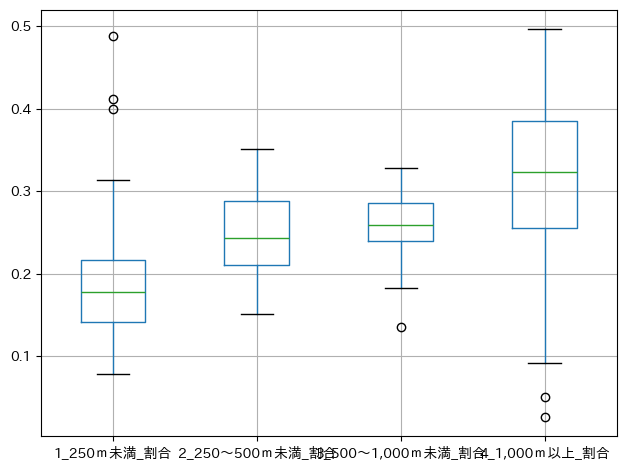

In [106]:
df_all.boxplot(column=['1_250ｍ未満_割合','2_250～500ｍ未満_割合','3_500～1,000ｍ未満_割合','4_1,000ｍ以上_割合'])
plt.tight_layout()
plt.show()

In [108]:
df_all[df_all['1_250ｍ未満_割合']>0.35]

,Unnamed: 0,地域区分,高齢世帯の型,住宅の所有の関係,0_総数,1_250ｍ未満,2_250～500ｍ未満,"3_500～1,000ｍ未満","4_1,000ｍ以上",1_250ｍ未満_割合,2_250～500ｍ未満_割合,"3_500～1,000ｍ未満_割合","4_1,000ｍ以上_割合"
1989,a,東京都,0_総数,0_総数,1531200.0,747800.0,536700.0,206600.0,40100.0,0.488375,0.350509,0.134927,0.026189
4446,a,京都府,0_総数,0_総数,315800.0,126100.0,91200.0,57500.0,40900.0,0.399303,0.288790,0.182077,0.129512
4680,a,大阪府,0_総数,0_総数,1144800.0,471700.0,380900.0,234000.0,58200.0,0.412037,0.332722,0.204403,0.050839


In [112]:
df_all[df_all['4_1,000ｍ以上_割合']<0.09]

,Unnamed: 0,地域区分,高齢世帯の型,住宅の所有の関係,0_総数,1_250ｍ未満,2_250～500ｍ未満,"3_500～1,000ｍ未満","4_1,000ｍ以上",1_250ｍ未満_割合,2_250～500ｍ未満_割合,"3_500～1,000ｍ未満_割合","4_1,000ｍ以上_割合"
1989,a,東京都,0_総数,0_総数,1531200.0,747800.0,536700.0,206600.0,40100.0,0.488375,0.350509,0.134927,0.026189
4680,a,大阪府,0_総数,0_総数,1144800.0,471700.0,380900.0,234000.0,58200.0,0.412037,0.332722,0.204403,0.050839


In [113]:
df_all[df_all['3_500～1,000ｍ未満_割合']<0.15]

,Unnamed: 0,地域区分,高齢世帯の型,住宅の所有の関係,0_総数,1_250ｍ未満,2_250～500ｍ未満,"3_500～1,000ｍ未満","4_1,000ｍ以上",1_250ｍ未満_割合,2_250～500ｍ未満_割合,"3_500～1,000ｍ未満_割合","4_1,000ｍ以上_割合"
1989,a,東京都,0_総数,0_総数,1531200.0,747800.0,536700.0,206600.0,40100.0,0.488375,0.350509,0.134927,0.026189


In [114]:
df_all.sort_values('4_1,000ｍ以上_割合',ascending=False)

,Unnamed: 0,地域区分,高齢世帯の型,住宅の所有の関係,0_総数,1_250ｍ未満,2_250～500ｍ未満,"3_500～1,000ｍ未満","4_1,000ｍ以上",1_250ｍ未満_割合,2_250～500ｍ未満_割合,"3_500～1,000ｍ未満_割合","4_1,000ｍ以上_割合"
468,a,岩手県,0_総数,0_総数,126000.0,11600.0,19000.0,32900.0,62500.0,0.092063,0.150794,0.261111,0.496032
351,a,青森県,0_総数,0_総数,132600.0,10300.0,22700.0,38800.0,60800.0,0.077677,0.171192,0.292609,0.458522
5616,a,島根県,0_総数,0_総数,76900.0,8800.0,16200.0,18300.0,33800.0,0.114434,0.210663,0.237971,0.439532
7839,a,鹿児島県,0_総数,0_総数,245500.0,35800.0,48900.0,54000.0,106900.0,0.145825,0.199185,0.219959,0.435438
6669,a,高知県,0_総数,0_総数,97800.0,15500.0,18600.0,22000.0,41700.0,0.158487,0.190184,0.224949,0.426380
819,a,秋田県,0_総数,0_総数,108200.0,13500.0,22000.0,27800.0,44900.0,0.124769,0.203327,0.256932,0.414972
7722,a,宮崎県,0_総数,0_総数,151800.0,21700.0,27100.0,40400.0,62700.0,0.142951,0.178524,0.266140,0.413043
7605,a,大分県,0_総数,0_総数,143100.0,20300.0,29000.0,34800.0,59100.0,0.141859,0.202655,0.243187,0.412998
1053,a,福島県,0_総数,0_総数,191200.0,30000.0,40600.0,42900.0,77700.0,0.156904,0.212343,0.224372,0.406381
1170,a,茨城県,0_総数,0_総数,305000.0,33200.0,62600.0,87100.0,122100.0,0.108852,0.205246,0.285574,0.400328


In [132]:
df_o65 = df[(df['Unnamed: 0']=='a')&(df['住宅の所有の関係']=='0_総数')&(df['地域区分']!='00000_全国')&(df['高齢世帯の型']!='0_総数')]

In [133]:
df_o65

,Unnamed: 0,地域区分,高齢世帯の型,住宅の所有の関係,0_総数,1_250ｍ未満,2_250～500ｍ未満,"3_500～1,000ｍ未満","4_1,000ｍ以上"
126,a,01000_北海道,1_65歳以上の単身世帯,0_総数,388600,82600,113800,104600,87600
135,a,01000_北海道,2_65歳以上の夫婦世帯,0_総数,367500,64700,97500,111200,94000
144,a,01000_北海道,21_いずれか一方のみが65歳以上夫婦,0_総数,54400,10600,13800,16600,13500
153,a,01000_北海道,22_夫婦とも65歳以上,0_総数,313100,54100,83800,94600,80500
162,a,01000_北海道,R1_（再掲）高齢夫婦世帯,0_総数,348200,61100,92500,105300,89300
...,...,...,...,...,...,...,...,...,...
8028,a,47000_沖縄県,R22_（（再掲）75歳以上の高齢者世帯）75歳以上の夫婦世帯,0_総数,23400,4100,6300,6100,6800
8037,a,47000_沖縄県,R221_（（再掲）75歳以上の高齢者世帯）いずれか一方のみが75歳以上夫婦,0_総数,8700,1200,2400,2100,3000
8046,a,47000_沖縄県,R222_（（再掲）75歳以上の高齢者世帯）夫婦とも75歳以上,0_総数,14700,2900,3900,4000,3800
8055,a,47000_沖縄県,S1_（別掲）65歳以上の世帯員のいる世帯,0_総数,228900,44300,66100,56600,61900


In [134]:
df_o65.info()

<class 'pandas.core.frame.DataFrame'>
Index: 564 entries, 126 to 8064
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Unnamed: 0      564 non-null    object
 1   地域区分            564 non-null    object
 2   高齢世帯の型          564 non-null    object
 3   住宅の所有の関係        564 non-null    object
 4   0_総数            564 non-null    object
 5   1_250ｍ未満        564 non-null    object
 6   2_250～500ｍ未満    564 non-null    object
 7   3_500～1,000ｍ未満  564 non-null    object
 8   4_1,000ｍ以上      564 non-null    object
dtypes: object(9)
memory usage: 44.1+ KB


In [127]:
df_o65 = df_o65[~df_o65['高齢世帯の型'].str.contains(r'R|S|別', na=False)]

In [128]:
df_o65

,Unnamed: 0,地域区分,高齢世帯の型,住宅の所有の関係,0_総数,1_250ｍ未満,2_250～500ｍ未満,"3_500～1,000ｍ未満","4_1,000ｍ以上"
126,a,01000_北海道,1_65歳以上の単身世帯,0_総数,388600,82600,113800,104600,87600
135,a,01000_北海道,2_65歳以上の夫婦世帯,0_総数,367500,64700,97500,111200,94000
144,a,01000_北海道,21_いずれか一方のみが65歳以上夫婦,0_総数,54400,10600,13800,16600,13500
153,a,01000_北海道,22_夫婦とも65歳以上,0_総数,313100,54100,83800,94600,80500
360,a,02000_青森県,1_65歳以上の単身世帯,0_総数,71900,6200,13300,21300,31100
...,...,...,...,...,...,...,...,...,...
7875,a,46000_鹿児島県,22_夫婦とも65歳以上,0_総数,100400,12100,19600,23200,45400
7965,a,47000_沖縄県,1_65歳以上の単身世帯,0_総数,80000,16100,26700,19400,17700
7974,a,47000_沖縄県,2_65歳以上の夫婦世帯,0_総数,55500,10300,14600,14100,16500
7983,a,47000_沖縄県,21_いずれか一方のみが65歳以上夫婦,0_総数,8500,1700,2200,2000,2500


In [139]:
df_o65['地域区分'] = df_o65['地域区分'].str.slice(6)

In [136]:
cols_to_int = [
    '0_総数',
    '1_250ｍ未満',
    '2_250～500ｍ未満',
    '3_500～1,000ｍ未満',
    '4_1,000ｍ以上',
    # '1_250ｍ未満_割合',
    # '2_250～500ｍ未満_割合',
    # '3_500～1,000ｍ未満_割合',
    # '4_1,000ｍ以上_割合'
]

# # 文字列を整数に変換（もし '-' がある場合は 0 に置換）
df_o65[cols_to_int] = df_o65[cols_to_int].replace('-', 0).astype(float)

C:\Users\junco\AppData\Local\Temp\ipykernel_8708\3404315655.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_o65[cols_to_int] = df_o65[cols_to_int].replace('-', 0).astype(float)


In [140]:
# 平均で集計
df_o65 = df_o65.groupby("地域区分", as_index=False).sum(numeric_only=True)

In [141]:
df_o65

,地域区分,0_総数,1_250ｍ未満,2_250～500ｍ未満,"3_500～1,000ｍ未満","4_1,000ｍ以上"
0,三重県,1199200.0,183400.0,304200.0,311900.0,400100.0
1,京都府,1824900.0,704900.0,522400.0,346800.0,250800.0
2,佐賀県,509600.0,57900.0,116000.0,144700.0,191200.0
3,兵庫県,3963800.0,1187700.0,1143400.0,948300.0,684200.0
4,北海道,4163000.0,774800.0,1133800.0,1211900.0,1042300.0
5,千葉県,4235000.0,942600.0,1206600.0,1234000.0,851600.0
6,和歌山県,749100.0,146400.0,185400.0,194500.0,222800.0
7,埼玉県,4774600.0,1297000.0,1495200.0,1369800.0,612700.0
8,大分県,840300.0,109400.0,160600.0,206700.0,363900.0
9,大阪府,6349900.0,2538000.0,2136200.0,1341000.0,334800.0


In [142]:
for col in distance_cols:
    df_o65[col + '_割合'] = df_o65[col] / df_o65['0_総数']

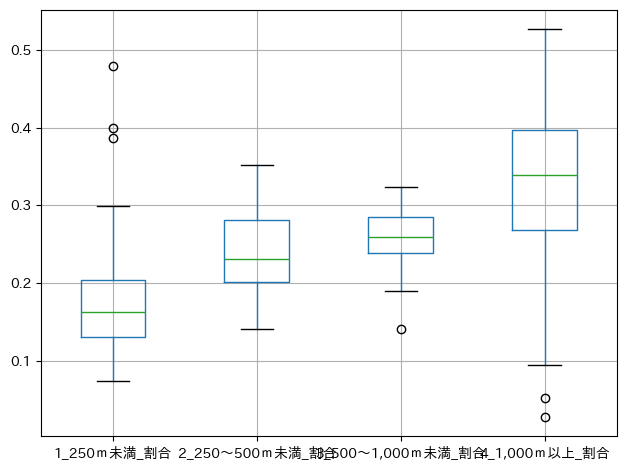

In [145]:
df_o65.boxplot(column=['1_250ｍ未満_割合','2_250～500ｍ未満_割合','3_500～1,000ｍ未満_割合','4_1,000ｍ以上_割合'])
plt.tight_layout()
plt.show()

In [146]:
df_o65.sort_values('4_1,000ｍ以上_割合',ascending=False)

,地域区分,0_総数,1_250ｍ未満,2_250～500ｍ未満,"3_500～1,000ｍ未満","4_1,000ｍ以上",1_250ｍ未満_割合,2_250～500ｍ未満_割合,"3_500～1,000ｍ未満_割合","4_1,000ｍ以上_割合"
19,岩手県,803900.0,68500.0,113500.0,199200.0,422900.0,0.085210,0.141187,0.247792,0.526060
41,青森県,814400.0,60900.0,134000.0,228700.0,391000.0,0.074779,0.164538,0.280820,0.480108
36,秋田県,691900.0,78100.0,132600.0,167600.0,313600.0,0.112878,0.191646,0.242232,0.453245
20,島根県,484400.0,53300.0,97800.0,117500.0,215900.0,0.110033,0.201899,0.242568,0.445706
44,高知県,559400.0,88100.0,100100.0,123900.0,247300.0,0.157490,0.178942,0.221487,0.442081
46,鹿児島県,1315600.0,184000.0,264200.0,292200.0,575200.0,0.139860,0.200821,0.222104,0.437215
35,福島県,1199800.0,171400.0,241600.0,266000.0,521100.0,0.142857,0.201367,0.221704,0.434322
8,大分県,840300.0,109400.0,160600.0,206700.0,363900.0,0.130192,0.191122,0.245984,0.433060
12,宮崎県,843800.0,114500.0,145600.0,224100.0,359300.0,0.135696,0.172553,0.265584,0.425812
38,茨城県,1905400.0,198700.0,370300.0,543200.0,792800.0,0.104283,0.194342,0.285084,0.416081
